Carga de librerias y datos

In [2]:
import pandas as pd
import geopandas as gpd
import os


if os.path.exists('data'):
    PATH_DATA = 'data'
elif os.path.exists(os.path.join('..', 'data')):
    PATH_DATA = os.path.join('..', 'data')
else:
    PATH_DATA = 'data'



# 2. CARGA DE DATOS LIMPIOS Y MAPA

# A. Datos Tabulares (Pandas)
df_listings = pd.read_csv(os.path.join(PATH_DATA, 'listings_limpio.csv'))
df_renta = pd.read_csv(os.path.join(PATH_DATA, 'renta_sevilla_capital_limpio.csv'))
df_calendar = pd.read_csv(os.path.join(PATH_DATA, 'calendar_limpio.csv.zip'), compression='zip', parse_dates=['date'])

# B. Datos Espaciales (Geopandas)
mapa_sevilla = gpd.read_file(os.path.join(PATH_DATA, 'mapa_sevilla.geojson'))



Preparación espacial de los datos

In [3]:
# Convertimos el DataFrame de Pandas en un GeoDataFrame de Geopandas
gdf_listings = gpd.GeoDataFrame(
    df_listings, 
    geometry=gpd.points_from_xy(df_listings.longitude, df_listings.latitude),
    crs="EPSG:4326" # CRS estándar de GPS (El que usa Airbnb)
)

# El mapa del INE usa coordenadas de España (EPSG:25830).
# Para cruzarlos, proyectamos los puntos de Airbnb al mismo sistema que el mapa.
if gdf_listings.crs != mapa_sevilla.crs:
    gdf_listings = gdf_listings.to_crs(mapa_sevilla.crs)


# Unimos cada piso con el polígono del mapa que lo contenga
pisos_con_seccion = gpd.sjoin(gdf_listings, mapa_sevilla, how="left", predicate="intersects")

# Para cruzar bien, nos aseguramos de que los códigos de 10 dígitos sean texto
pisos_con_seccion['CUSEC'] = pisos_con_seccion['CUSEC'].astype(str)
df_renta['Secciones'] = df_renta['Secciones'].astype(str)

# Hacemos un Merge usando el código de sección del INE
datos_finales = pd.merge(
    pisos_con_seccion, 
    df_renta[['Secciones', 'Total']], # Solo traemos la columna Total (Renta)
    left_on='CUSEC', 
    right_on='Secciones', 
    how='left'
)

print(f"Dimensiones finales del dataset maestro: {datos_finales.shape}")

Dimensiones finales del dataset maestro: (8215, 42)


Prueba de visualizado del mapa (provisional)

📍 Preparando la visualización espacial...


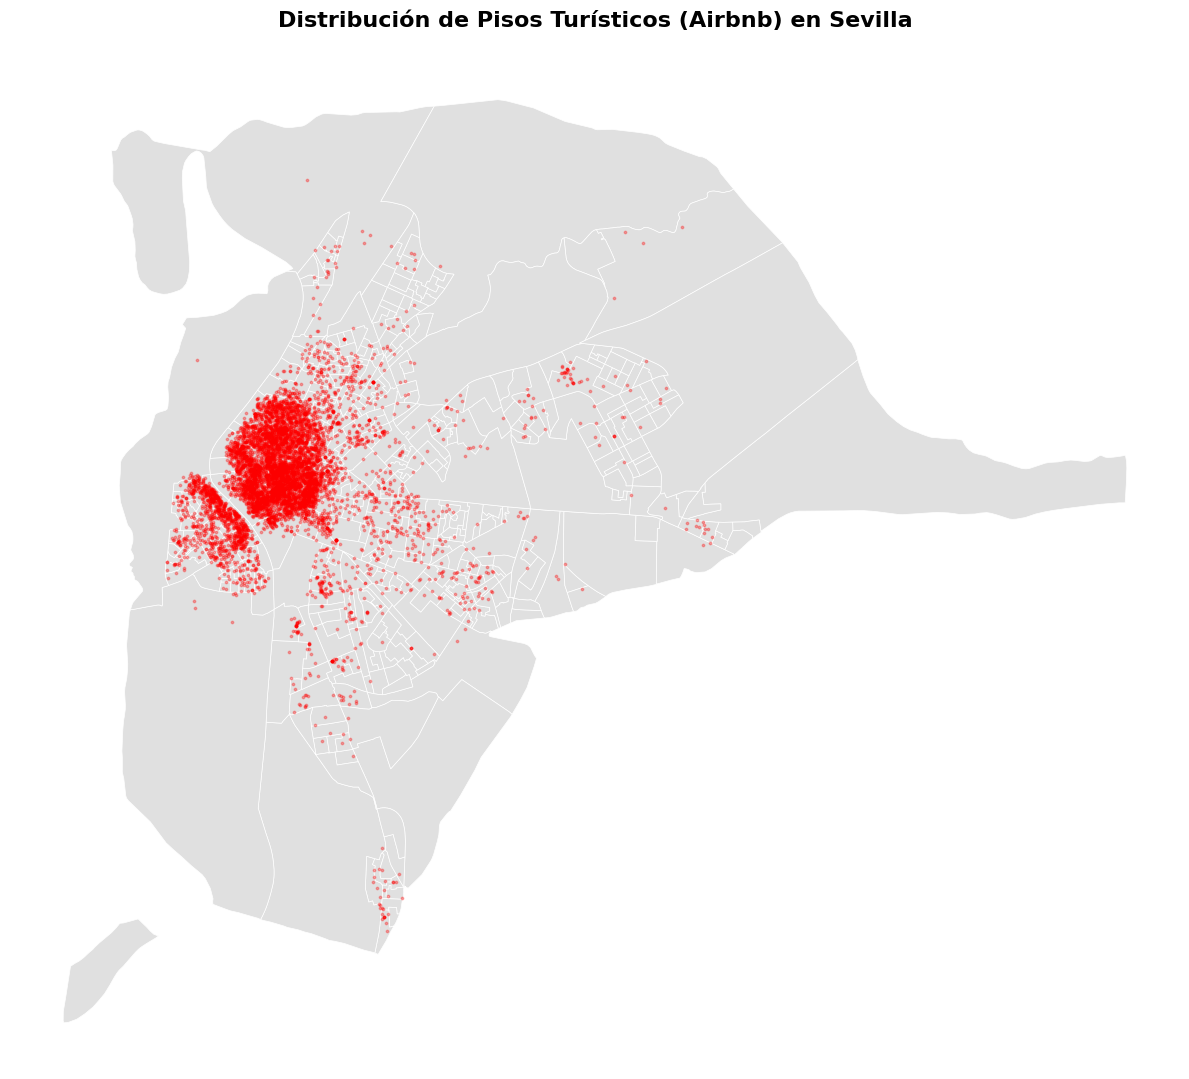

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd


# 1. Convertir los pisos de Airbnb (df_listings) en PUNTOS en el mapa
# Le pasamos la longitud (X) y la latitud (Y)
gdf_listings = gpd.GeoDataFrame(
    df_listings, 
    geometry=gpd.points_from_xy(df_listings.longitude, df_listings.latitude),
    crs="EPSG:4326" # CRS global (GPS) que usa Airbnb
)

# 2. SINCRONIZACIÓN DE COORDENADAS (Paso vital)
gdf_listings = gdf_listings.to_crs(mapa_sevilla.crs)

# 3. DIBUJAR EL MAPA
fig, ax = plt.subplots(figsize=(12, 12))

# Capa 1: Pintar los polígonos de Sevilla (Gris claro con bordes blancos)
mapa_sevilla.plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)

# Capa 2: Pintar los pisos de Airbnb por encima (Puntitos rojos semitransparentes)
# El alpha=0.3 hace que si hay muchos pisos juntos, el color se vea más oscuro
gdf_listings.plot(ax=ax, color='red', markersize=3, alpha=0.3)

# 4. ESTÉTICA
ax.set_title('Distribución de Pisos Turísticos (Airbnb) en Sevilla', fontsize=16, fontweight='bold', pad=20)
ax.axis('off') # Ocultamos el eje X e Y para que parezca un cuadro y no una gráfica matemática

plt.tight_layout()
plt.show()